In [4]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import mean_squared_error, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import GridSearchCV

In [6]:
%matplotlib inline

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
dataset = pd.read_csv('/content/Teen_Mental_Health_Dataset.csv')

In [9]:
dataset.head(300)

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,13,male,6.4,Both,8.3,1.3,2.21,1.2,high,4,5,9,0
296,19,male,6.4,Both,6.7,2.4,2.20,1.3,low,5,2,2,0
297,17,female,1.1,Instagram,9.0,2.9,2.74,1.0,medium,2,8,2,0
298,13,male,1.3,TikTok,7.8,2.6,3.01,0.3,low,2,9,10,0


In [10]:
dataset = dataset.dropna()

In [11]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 122.0+ KB


In [12]:
df = pd.read_csv('Teen_Mental_Health_Dataset.csv')

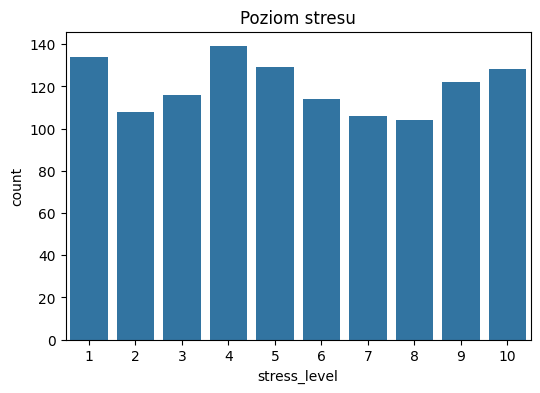

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='stress_level')
plt.title('Poziom stresu')
plt.show()

In [14]:
df["stress_level"].value_counts()

,count
stress_level,
4,139
1,134
5,129
10,128
9,122
3,116
6,114
2,108
7,106


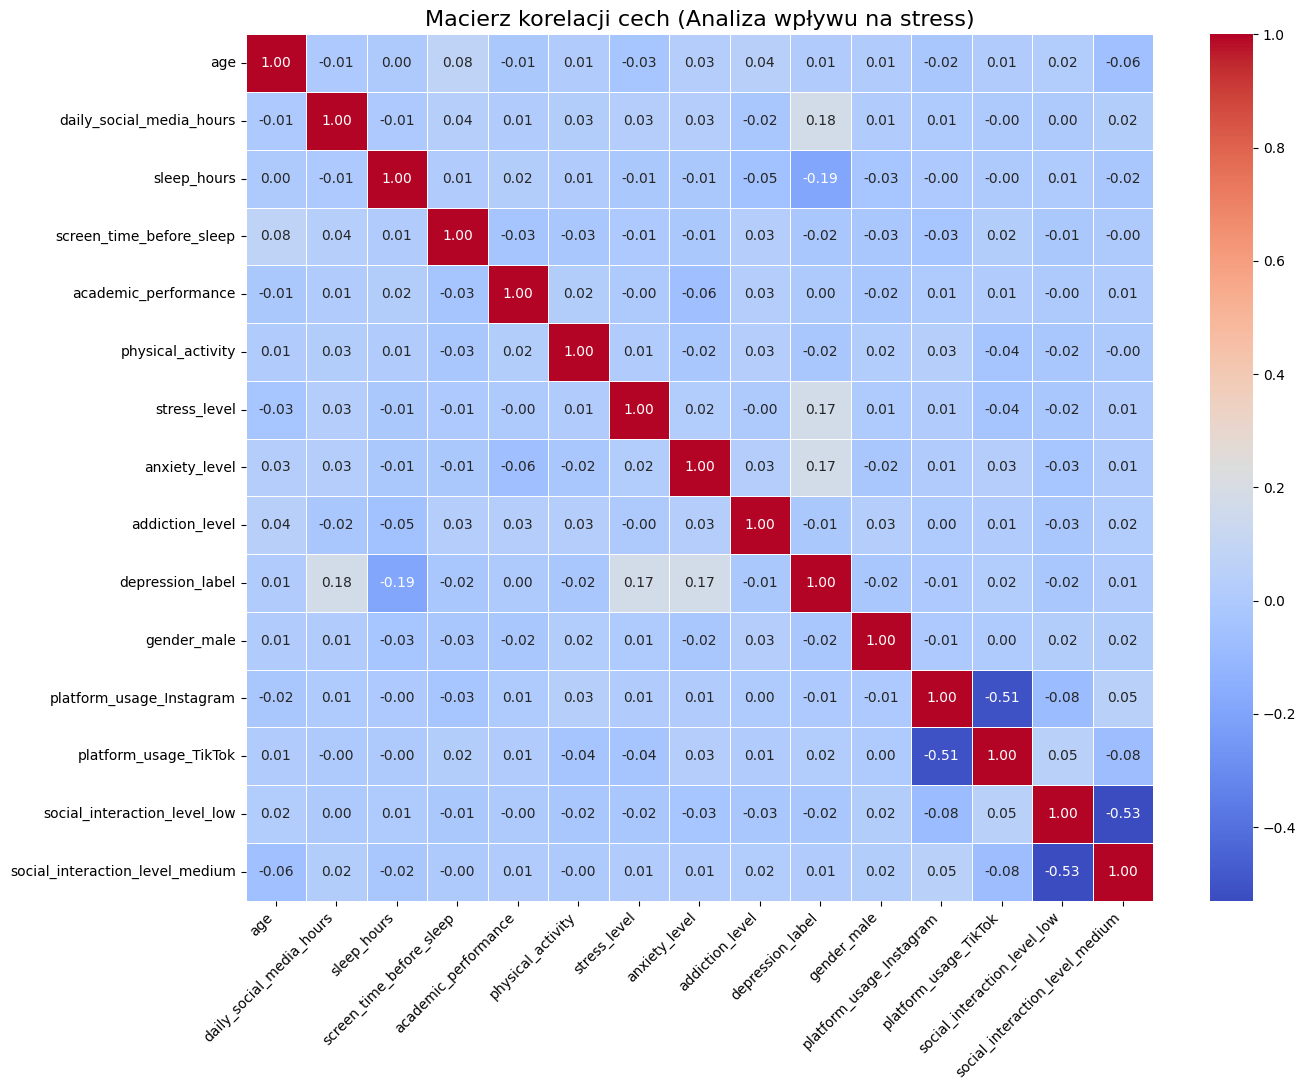

Korelacja cech bezpośrednio skorelowanych ze zmienną 'stress_level':
stress_level                       1.000000
depression_label                   0.170474
daily_social_media_hours           0.030698
anxiety_level                      0.015811
platform_usage_Instagram           0.013169
physical_activity                  0.012159
social_interaction_level_medium    0.009372
gender_male                        0.007935
addiction_level                   -0.000129
academic_performance              -0.000600
screen_time_before_sleep          -0.008650
sleep_hours                       -0.010979
social_interaction_level_low      -0.024161
age                               -0.031208
platform_usage_TikTok             -0.038083
Name: stress_level, dtype: float64


In [15]:
df_encoded = pd.get_dummies(df, drop_first=True)

corr_matrix = df_encoded.corr()

plt.figure(figsize=(14, 11))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Macierz korelacji cech (Analiza wpływu na stress)', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Korelacja cech bezpośrednio skorelowanych ze zmienną 'stress_level':")
print(corr_matrix['stress_level'].sort_values(ascending=False))

In [16]:
df.describe()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


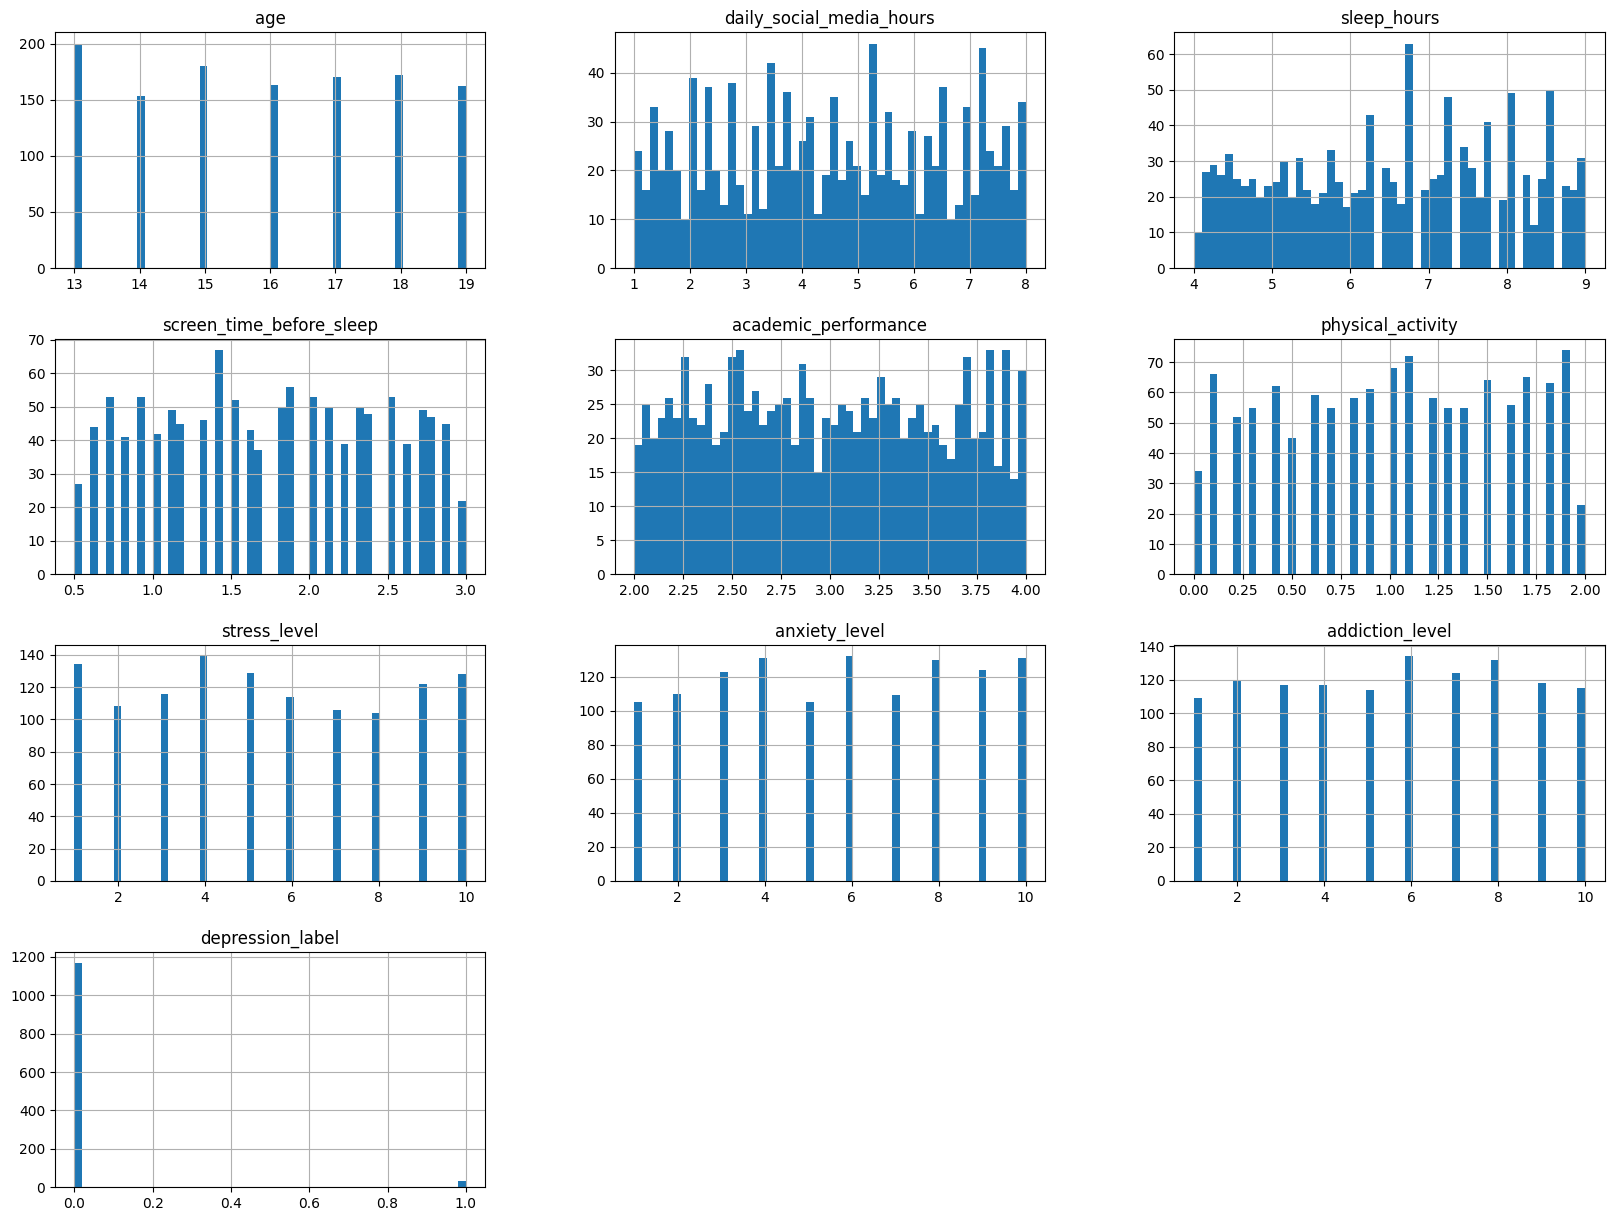

In [17]:
df.hist(bins=50, figsize=(20,15))
plt.show()

In [18]:
# Wczytanie zbioru danych dotyczącego zdrowia psychicznego nastolatków
df = pd.read_csv('Teen_Mental_Health_Dataset.csv')

# Definiujemy zmienną docelową: przyjmujemy próg >= 6 jako 'Wysoki Stres' (1), a poniżej jako 'Niski/Średni Stres' (0)
# Pozwala to na rozwiązanie problemu klasyfikacji binarnej
df['czy_wysoki_stres'] = (df['stress_level'] >= 6).astype(int)

print(f"Liczba wierszy i kolumn w zbiorze: {df.shape}")
print("\nRozkład zmiennej docelowej (czy wysoki stres):")
print(df['czy_wysoki_stres'].value_counts(normalize=True))

Liczba wierszy i kolumn w zbiorze: (1200, 14)

Rozkład zmiennej docelowej (czy wysoki stres):
czy_wysoki_stres
0    0.521667
1    0.478333
Name: proportion, dtype: float64


In [19]:
# 1. Mapowanie zmiennej porządkowej 'social_interaction_level' na wartości numeryczne
df['social_interaction_encoded'] = df['social_interaction_level'].map({'low': 0, 'medium': 1, 'high': 2})

# 2. Kodowanie zmiennych nominalnych ('gender', 'platform_usage') za pomocą One-Hot Encoding
# drop_first=True pozwala uniknąć pułapki współliniowości (dummy variable trap)
df_encoded = pd.get_dummies(df, columns=['gender', 'platform_usage'], drop_first=True)

# 3. Wybór zmiennych wejściowych (X) oraz zmiennej docelowej (y)
# Wykluczamy pierwotną kolumnę 'stress_level' (aby uniknąć wycieku informacji) oraz stare kolumny tekstowe
zmienne_wejsciowe = [
    'age', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep',
    'academic_performance', 'physical_activity', 'social_interaction_encoded',
    'anxiety_level', 'addiction_level', 'depression_label',
    'gender_male', 'platform_usage_Instagram', 'platform_usage_TikTok'
]

X = df_encoded[zmienne_wejsciowe]
y = df_encoded['czy_wysoki_stres']

print("Wybrane zmienne wejściowe do modeli:")
print(X.columns.tolist())

Wybrane zmienne wejściowe do modeli:
['age', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'social_interaction_encoded', 'anxiety_level', 'addiction_level', 'depression_label', 'gender_male', 'platform_usage_Instagram', 'platform_usage_TikTok']


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Skalowanie cech jest kluczowe dla zbalansowania wag modeli (szczególnie Regresji Logistycznej)
scaler = StandardScaler()

# Dopasowujemy scaler TYLKO do zbioru treningowego i transformujemy go
X_train_scaled = scaler.fit_transform(X_train)

# Zbiór testowy jedynie transformujemy za pomocą parametrów wyliczonych z treningu
X_test_scaled = scaler.transform(X_test)

print(f"Rozmiar zbioru treningowego: {X_train.shape}")
print(f"Rozmiar zbioru testowego: {X_test.shape}")

Rozmiar zbioru treningowego: (960, 13)
Rozmiar zbioru testowego: (240, 13)


In [21]:
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2']
}

param_grid_dt = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5]
}

print("Rozpoczynanie optymalizacji modeli za pomocą GridSearchCV...")

# 1. Regresja Logistyczna
grid_lr = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42), param_grid_lr, cv=5, scoring='f1')
grid_lr.fit(X_train_scaled, y_train)

# 2. Drzewo Decyzyjne
grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid_dt, cv=5, scoring='f1')
grid_dt.fit(X_train_scaled, y_train)

# 3. Las Losowy (Random Forest)
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5, scoring='f1')
grid_rf.fit(X_train_scaled, y_train)

# Wyświetlenie najlepszych wyników walidacji krzyżowej (metryka F1-score)
print("\n--- WYNIKI KROSWALIDACJI NA ZBIORZE TRENINGOWYM ---")
print(f"Regresja Logistyczna -> Najlepsze F1: {grid_lr.best_score_:.4f} przy parametrach: {grid_lr.best_params_}")
print(f"Drzewo Decyzyjne     -> Najlepsze F1: {grid_dt.best_score_:.4f} przy parametrach: {grid_dt.best_params_}")
print(f"Random Forest        -> Najlepsze F1: {grid_rf.best_score_:.4f} przy parametrach: {grid_rf.best_params_}")


Rozpoczynanie optymalizacji modeli za pomocą GridSearchCV...

--- WYNIKI KROSWALIDACJI NA ZBIORZE TRENINGOWYM ---
Regresja Logistyczna -> Najlepsze F1: 0.3226 przy parametrach: {'C': 10, 'penalty': 'l2'}
Drzewo Decyzyjne     -> Najlepsze F1: 0.4883 przy parametrach: {'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 2}
Random Forest        -> Najlepsze F1: 0.4803 przy parametrach: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 50}


In [23]:
wyniki_cv = {
    'Logistic Regression': grid_lr.best_score_,
    'Decision Tree': grid_dt.best_score_,
    'Random Forest': grid_rf.best_score_
}

najlepszy_model_nazwa = max(wyniki_cv, key=wyniki_cv.get)
print(f"Najlepszy model na podstawie walidacji krzyżowej: {najlepszy_model_nazwa}\n")

# Przypisanie najlepszego estymatora
if najlepszy_model_nazwa == 'Logistic Regression':
    najlepszy_model = grid_lr.best_estimator_
elif najlepszy_model_nazwa == 'Decision Tree':
    najlepszy_model = grid_dt.best_estimator_
else:
    najlepszy_model = grid_rf.best_estimator_

# DOPIERO TERAZ używamy zbioru testowego do ostatecznej oceny działania modelu
y_pred_final = najlepszy_model.predict(X_test_scaled)

print(f"=== OSTATECZNY RAPORT KLASYFIKACJI DLA MODELU: {najlepszy_model_nazwa.upper()} ===")
target_names = ['Niski/Średni Stres (0)', 'Wysoki Stres (1)']
print(classification_report(y_test, y_pred_final, target_names=target_names))

print("=== MACIERZ POMYŁEK ===")
print(confusion_matrix(y_test, y_pred_final))

Najlepszy model na podstawie walidacji krzyżowej: Decision Tree

=== OSTATECZNY RAPORT KLASYFIKACJI DLA MODELU: DECISION TREE ===
                        precision    recall  f1-score   support

Niski/Średni Stres (0)       0.47      0.47      0.47       125
      Wysoki Stres (1)       0.43      0.43      0.43       115

              accuracy                           0.45       240
             macro avg       0.45      0.45      0.45       240
          weighted avg       0.45      0.45      0.45       240

=== MACIERZ POMYŁEK ===
[[59 66]
 [66 49]]
